# **Import thư viện**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

print('...Tất cả thư viện đã được import thành công!')

...Tất cả thư viện đã được import thành công!


# **EDA**

## **Bộ dữ liệu domain_worker_desires**

In [2]:
df_desires = pd.read_csv('workbank/domain_worker_desires.csv')
display(df_desires.head(10))

,Task ID,Occupation (O*NET-SOC Title),Task,User ID,Date,Self-reported Expertise,Automation Desire Rating,Time,Core Skill Rating,Job Security Rating,...,Human Agency Scale Rating,Reasons for Human Agency - Physical,Reasons for Human Agency - Control,Reasons for Human Agency - Domain Knowledge,Reasons for Human Agency - Empathy,Reasons for Human Agency - Quality Oversight,Reasons for Human Agency - Dynamic,Reasons for Human Agency - Ethical,Other Reason for Automation Desire,Other Reason for Human Agency
0,21520,Accountants and Auditors,Report to management regarding the finances of...,9aef09c6-ccfd-4dc0-a578-1ae21f7450a1,21/01/2025,Expert,4,1,3,3,...,5,True,True,True,True,True,True,True,NaN,NaN
1,21511,Accountants and Auditors,Examine and evaluate financial and information...,9ee73f2c-d7a0-4f7f-be1c-a2a0477c8d09,04/02/2025,Average,1,1,3,4,...,5,True,True,True,True,True,True,True,FALSE,NaN
2,21514,Accountants and Auditors,"Prepare, examine, or analyze accounting record...",9ee73f2c-d7a0-4f7f-be1c-a2a0477c8d09,04/02/2025,Expert,1,4,4,1,...,5,True,True,True,True,True,True,True,FALSE,NaN
3,21515,Accountants and Auditors,Prepare adjusting journal entries.,9ee73f2c-d7a0-4f7f-be1c-a2a0477c8d09,04/02/2025,Average,1,1,4,1,...,5,True,True,True,True,True,True,True,FALSE,NaN
4,21516,Accountants and Auditors,Review accounts for discrepancies and reconcil...,9ee73f2c-d7a0-4f7f-be1c-a2a0477c8d09,04/02/2025,Expert,1,4,4,1,...,1,False,False,False,False,False,False,False,FALSE,FALSE
5,21519,Accountants and Auditors,"Analyze business operations, trends, costs, re...",9ee73f2c-d7a0-4f7f-be1c-a2a0477c8d09,04/02/2025,Average,1,2,4,1,...,5,True,True,True,True,True,True,True,FALSE,NaN
6,21520,Accountants and Auditors,Report to management regarding the finances of...,9ee73f2c-d7a0-4f7f-be1c-a2a0477c8d09,04/02/2025,Average,1,2,4,1,...,1,False,False,False,False,False,False,False,FALSE,FALSE
7,21522,Accountants and Auditors,Evaluate taxpayer finances to determine tax li...,9ee73f2c-d7a0-4f7f-be1c-a2a0477c8d09,04/02/2025,Average,1,1,3,1,...,5,True,True,True,True,True,True,True,FALSE,NaN
8,21514,Accountants and Auditors,"Prepare, examine, or analyze accounting record...",83877fbe-1249-44a9-874a-f6d83b4b557a,04/02/2025,Novice,1,1,2,1,...,3,False,False,False,False,True,False,True,FALSE,NaN
9,21515,Accountants and Auditors,Prepare adjusting journal entries.,83877fbe-1249-44a9-874a-f6d83b4b557a,04/02/2025,Average,5,2,4,1,...,2,False,False,False,False,False,False,False,NaN,FALSE


In [3]:
print('Kích thước dữ liệu domain_worker_desires:', df_desires.shape)
print('\nKiểu dữ liệu:'); display(df_desires.dtypes)
print('\nGiá trị thiếu:'); display(df_desires.isna().sum())

Kích thước dữ liệu domain_worker_desires: (5731, 31)

Kiểu dữ liệu:


Task ID                                         int64
Occupation (O*NET-SOC Title)                      str
Task                                              str
User ID                                           str
Date                                              str
Self-reported Expertise                           str
Automation Desire Rating                        int64
Time                                            int64
Core Skill Rating                               int64
Job Security Rating                             int64
Enjoyment Rating                                int64
Reasons for Automation Desire - Free Time        bool
Reasons for Automation Desire - Repetitive       bool
Reasons for Automation Desire - Human Error      bool
Reasons for Automation Desire - Stress           bool
Reasons for Automation Desire - Difficulty       bool
Reasons for Automation Desire - Scale            bool
Physical Action Requirement                     int64
Interpersonal Communication 


Giá trị thiếu:


Task ID                                            0
Occupation (O*NET-SOC Title)                       0
Task                                               0
User ID                                            0
Date                                               0
Self-reported Expertise                            0
Automation Desire Rating                           0
Time                                               0
Core Skill Rating                                  0
Job Security Rating                                0
Enjoyment Rating                                   0
Reasons for Automation Desire - Free Time          0
Reasons for Automation Desire - Repetitive         0
Reasons for Automation Desire - Human Error        0
Reasons for Automation Desire - Stress             0
Reasons for Automation Desire - Difficulty         0
Reasons for Automation Desire - Scale              0
Physical Action Requirement                        0
Interpersonal Communication Requirement       

## **Bộ dữ liệu domain_worker_metadata**

In [4]:
df_metadata = pd.read_csv('workbank/domain_worker_metadata.csv')
display(df_metadata.head(10))

,User ID,Occupation (O*NET-SOC Title),Gender,Race,Income,Age,Education,Experience,AI Tedious Work Attitude,AI Job Importance Attitude,...,LLM Usage by Type - Information Access,LLM Usage by Type - Edit,LLM Usage by Type - Idea Generation,LLM Usage by Type - Communication,LLM Usage by Type - Analysis,LLM Usage by Type - Decision,LLM Usage by Type - Coding,LLM Usage by Type - System Design,LLM Usage by Type - Data Processing,Recruitment Source
0,a17b322e-3134-475c-a652-89f27b3a9946,Medical and Health Services Managers,Female,White,60-86K,30,"Professional Degree (e.g., MD, JD)",1-2 year,Somewhat agree,Neither agree nor disagree,...,Daily,Never,Never,Never,Weekly,Weekly,Never,Never,Monthly,Prolific
1,533a6bf0-9958-4892-8777-44108350b9be,Customer Service Representatives,Male,Asian American and Pacific Islander,86K-165K,28,Bachelor’s Degree,6-10 years,Somewhat agree,Somewhat agree,...,Weekly,Weekly,Daily,Daily,Weekly,Daily,Weekly,Never,Weekly,Prolific
2,9f48da63-2e55-413d-a8b4-ec18e410eb36,Mechanical Engineers,Male,Black,30-60K,34,Bachelor’s Degree,6-10 years,Strongly agree,Strongly agree,...,Weekly,Daily,Daily,Daily,Daily,Daily,Never,Never,Never,Prolific
3,32176135-796f-4d69-811a-b26a9dfc0c3c,Editors,Female,White,60-86K,53,Bachelor’s Degree,More than 10 years,Somewhat agree,Neither agree nor disagree,...,Never,Monthly,Never,Never,Never,Never,Never,Never,Never,Prolific
4,f5ebd9c8-d0f3-4e08-8027-5680268d073d,Computer Network Support Specialists,Male,White,86K-165K,39,Bachelor’s Degree,6-10 years,Somewhat agree,Somewhat agree,...,Weekly,Weekly,Monthly,Daily,Daily,Daily,Weekly,Weekly,Weekly,Prolific
5,9aef09c6-ccfd-4dc0-a578-1ae21f7450a1,Accountants and Auditors,Male,Black,30-60K,24,Master’s Degree,3-5 years,Strongly agree,Strongly agree,...,Daily,Daily,Weekly,Daily,Daily,Daily,Daily,Daily,Daily,Prolific
6,231576cd-4cc2-4dee-91cb-6bb0105d06db,Information Technology Project Managers,Male,White,60-86K,25,Bachelor’s Degree,3-5 years,Strongly agree,Somewhat disagree,...,Never,Weekly,Never,Weekly,Never,Never,Monthly,Never,Weekly,Prolific
7,1e0f35ea-7f4c-49f2-bb5a-d1e4fecc221a,"Sales Representatives, Wholesale and Manufactu...",Male,White,86K-165K,60,Bachelor’s Degree,6-10 years,Strongly agree,Strongly disagree,...,Never,Monthly,Never,Weekly,Never,Never,Never,Never,Daily,Prolific
8,1ea438f6-b348-41ef-a3b7-0d3ea26da742,Computer Systems Engineers/Architects,Male,White,209K-529K,52,"Some College, No Degree",More than 10 years,Somewhat agree,Somewhat disagree,...,Weekly,Weekly,Weekly,Weekly,Weekly,Weekly,Weekly,Weekly,Weekly,Prolific
9,52cdb85b-5307-450a-ac44-b51194f76036,"Sales Representatives, Wholesale and Manufactu...",Male,White,Prefer not to say,54,Bachelor’s Degree,More than 10 years,Strongly agree,Somewhat agree,...,Never,Never,Never,Never,Never,Never,Never,Never,Never,Prolific


In [5]:
print('Kích thước dữ liệu domain_worker_metadata:', df_metadata.shape)
print('\nKiểu dữ liệu:'); display(df_metadata.dtypes)
print('\nGiá trị thiếu:'); display(df_metadata.isna().sum())
print('\nUnique Zip Code:', df_metadata['Zip Code'].unique())
print('\nUnique LLM Usage by Type - Information Access:', df_metadata['LLM Usage by Type - Information Access'].unique())
print('\nUnique LLM Usage by Type - Edit:', df_metadata['LLM Usage by Type - Edit'].unique())
print('\nUnique LLM Usage by Type - Idea Generation:', df_metadata['LLM Usage by Type - Idea Generation'].unique())
print('\nUnique LLM Usage by Type - Communication:', df_metadata['LLM Usage by Type - Communication'].unique())
print('\nUnique LLM Usage by Type - Analysis:', df_metadata['LLM Usage by Type - Analysis'].unique())
print('\nUnique LLM Usage by Type - Decision:', df_metadata['LLM Usage by Type - Decision'].unique())
print('\nUnique LLM Usage by Type - Coding:', df_metadata['LLM Usage by Type - Coding'].unique())
print('\nUnique LLM Usage by Type - System Design:', df_metadata['LLM Usage by Type - System Design'].unique())
print('\nUnique LLM Usage by Type - Data Processing:', df_metadata['LLM Usage by Type - Data Processing'].unique())

Kích thước dữ liệu domain_worker_metadata: (1500, 26)

Kiểu dữ liệu:


User ID                                     str
Occupation (O*NET-SOC Title)                str
Gender                                      str
Race                                        str
Income                                      str
Age                                       int64
Education                                   str
Experience                                  str
AI Tedious Work Attitude                    str
AI Job Importance Attitude                  str
AI Daily Interest Attitude                  str
AI Suffering Attitude                       str
Zip Code                                    str
Political Affiliation                       str
LLM Familiarity                             str
LLM Use in Work                             str
LLM Usage by Type - Information Access      str
LLM Usage by Type - Edit                    str
LLM Usage by Type - Idea Generation         str
LLM Usage by Type - Communication           str
LLM Usage by Type - Analysis            


Giá trị thiếu:


User ID                                     0
Occupation (O*NET-SOC Title)                0
Gender                                      0
Race                                        0
Income                                      0
Age                                         0
Education                                   0
Experience                                  0
AI Tedious Work Attitude                    0
AI Job Importance Attitude                  0
AI Daily Interest Attitude                  0
AI Suffering Attitude                       0
Zip Code                                  802
Political Affiliation                       0
LLM Familiarity                             0
LLM Use in Work                             0
LLM Usage by Type - Information Access    272
LLM Usage by Type - Edit                  272
LLM Usage by Type - Idea Generation       272
LLM Usage by Type - Communication         272
LLM Usage by Type - Analysis              272
LLM Usage by Type - Decision      


Unique Zip Code: <ArrowStringArray>
[    nan, '10010',  '6438', '22043',  '7207',  '2155', '96789', '23919',
 '21203', '90001',
 ...
 '94086', '89145', '40744', '30458', '70586', '28351', '83805', '47712',
 '48075', '98201']
Length: 641, dtype: str

Unique LLM Usage by Type - Information Access: <ArrowStringArray>
['Daily', 'Weekly', 'Never', 'Monthly', nan]
Length: 5, dtype: str

Unique LLM Usage by Type - Edit: <ArrowStringArray>
['Never', 'Weekly', 'Daily', 'Monthly', nan]
Length: 5, dtype: str

Unique LLM Usage by Type - Idea Generation: <ArrowStringArray>
['Never', 'Daily', 'Monthly', 'Weekly', nan]
Length: 5, dtype: str

Unique LLM Usage by Type - Communication: <ArrowStringArray>
['Never', 'Daily', 'Weekly', 'Monthly', nan]
Length: 5, dtype: str

Unique LLM Usage by Type - Analysis: <ArrowStringArray>
['Weekly', 'Daily', 'Never', 'Monthly', nan]
Length: 5, dtype: str

Unique LLM Usage by Type - Decision: <ArrowStringArray>
['Weekly', 'Daily', 'Never', 'Monthly', nan]
Length: 5,

## **Bộ dữ liệu expert_rated_technological_capability**

In [6]:
df_expert = pd.read_csv('workbank/expert_rated_technological_capability.csv')
display(df_expert.head(10))

,Task ID,Occupation (O*NET-SOC Title),Task,User ID,Date,Automation Capacity Rating,Physical Action Requirement,Involved Uncertainty,Domain Expertise Requirement,Interpersonal Communication Requirement,Human Agency Scale Rating
0,3226,Advertising and Promotions Managers,"Inspect layouts and advertising copy, and edit...",RedTiger,16/03/2025,4,1,1,2,1,2
1,21567,Appraisers and Assessors of Real Estate,Verify legal descriptions of properties by com...,YellowZebra,16/03/2025,3,1,2,4,1,2
2,3970,Technical Writers,Review published materials and recommend revis...,BrownFox,18/03/2025,4,3,3,3,3,3
3,22655,Writers and Authors,Vary language and tone of messages based on pr...,BrownFox,19/03/2025,4,1,1,2,1,2
4,22654,Writers and Authors,Present drafts and ideas to clients.,BrownFox,19/03/2025,3,3,1,3,5,3
5,22660,Writers and Authors,"Review advertising trends, consumer surveys, a...",BrownFox,19/03/2025,5,1,1,2,1,2
6,22657,Writers and Authors,"Write articles, bulletins, sales letters, spee...",BrownFox,19/03/2025,4,1,1,2,1,2
7,22658,Writers and Authors,Conduct research and interviews to determine w...,BrownFox,19/03/2025,4,1,3,3,1,2
8,8961,Statisticians,Design research projects that apply valid scie...,OrangeWolf,24/03/2025,1,1,3,3,4,4
9,16246,Biostatisticians,Calculate sample size requirements for clinica...,OrangeWolf,24/03/2025,3,1,1,1,1,2


In [7]:
print('Kích thước dữ liệu domain_worker_desires:', df_expert.shape)
print('\nKiểu dữ liệu:'); display(df_expert.dtypes)
print('\nGiá trị thiếu:'); display(df_expert.isna().sum())

Kích thước dữ liệu domain_worker_desires: (2057, 11)

Kiểu dữ liệu:


Task ID                                    int64
Occupation (O*NET-SOC Title)                 str
Task                                         str
User ID                                      str
Date                                         str
Automation Capacity Rating                 int64
Physical Action Requirement                int64
Involved Uncertainty                       int64
Domain Expertise Requirement               int64
Interpersonal Communication Requirement    int64
Human Agency Scale Rating                  int64
dtype: object


Giá trị thiếu:


Task ID                                    0
Occupation (O*NET-SOC Title)               0
Task                                       0
User ID                                    0
Date                                       0
Automation Capacity Rating                 0
Physical Action Requirement                0
Involved Uncertainty                       0
Domain Expertise Requirement               0
Interpersonal Communication Requirement    0
Human Agency Scale Rating                  0
dtype: int64

## **Bộ dữ liệu task_statement_with_metadata**

In [8]:
df_task = pd.read_csv('workbank/task_statement_with_metadata.csv')
display(df_task.head(10))

,O*NET-SOC Code,Occupation (O*NET-SOC Title),Task ID,Task,Task Type,Date,Category,Frequency,Importance,Relevance,Occupation Mean Annual Wage,Occupation Employment,Skill (O*NET Work Activity),Skill ID (O*NET Generalized Work Activity ID)
0,11-2011.00,Advertising and Promotions Managers,3226,"Inspect layouts and advertising copy, and edit...",Core,Aug-18,3,3,4.07,87.26,149270.0,21100.0,['Evaluating Information to Determine Complian...,['4.A.2.a.3']
1,11-2011.00,Advertising and Promotions Managers,3242,Coordinate with the media to disseminate adver...,Core,Aug-18,3,3,3.87,80.19,149270.0,21100.0,"['Communicating with Supervisors, Peers, or Su...",['4.A.4.a.2']
2,11-2011.00,Advertising and Promotions Managers,3223,Prepare budgets and submit estimates for progr...,Core,Aug-18,3,3,3.67,81.73,149270.0,21100.0,"['Guiding, Directing, and Motivating Subordina...",['4.A.4.b.4']
3,11-2011.00,Advertising and Promotions Managers,3243,Contact organizations to explain services and ...,Core,Aug-18,5,5,3.61,79.02,149270.0,21100.0,['Selling or Influencing Others'],['4.A.4.a.6']
4,11-2011.00,Advertising and Promotions Managers,3233,Monitor and analyze sales promotion results to...,Core,Aug-18,3,3,3.59,77.04,149270.0,21100.0,['Analyzing Data or Information'],['4.A.2.a.4']
5,11-2011.00,Advertising and Promotions Managers,3234,Read trade journals and professional literatur...,Core,Aug-18,3,3,3.25,86.55,149270.0,21100.0,['Updating and Using Relevant Knowledge'],['4.A.2.b.3']
6,11-2021.00,Marketing Managers,951,"Identify, develop, or evaluate marketing strat...",Core,Jul-15,5,5,4.30,98.32,171520.0,384980.0,"['Judging the Qualities of Objects, Services, ...","['4.A.2.a.1', '4.A.2.b.2']"
7,11-2021.00,Marketing Managers,957,Compile lists describing product or service of...,Core,Jul-15,3,3,3.70,84.10,171520.0,384980.0,['Processing Information'],['4.A.2.a.2']
8,11-3012.00,Administrative Services Managers,21,Prepare and review operational reports and sch...,Core,Jul-17,5,5,3.71,77.98,126030.0,254140.0,['Documenting/Recording Information'],['4.A.3.b.6']
9,11-3012.00,Administrative Services Managers,20,Set goals and deadlines for the department.,Core,Jul-17,5,5,3.70,92.79,126030.0,254140.0,['Thinking Creatively'],['4.A.2.b.2']


In [9]:
print('Kích thước dữ liệu domain_worker_desires:', df_task.shape)
print('\nKiểu dữ liệu:'); display(df_task.dtypes)
print('\nGiá trị thiếu:'); display(df_task.isna().sum())

Kích thước dữ liệu domain_worker_desires: (2131, 14)

Kiểu dữ liệu:


O*NET-SOC Code                                       str
Occupation (O*NET-SOC Title)                         str
Task ID                                            int64
Task                                                 str
Task Type                                            str
Date                                                 str
Category                                           int64
Frequency                                          int64
Importance                                       float64
Relevance                                        float64
Occupation Mean Annual Wage                      float64
Occupation Employment                            float64
Skill (O*NET Work Activity)                          str
Skill ID (O*NET Generalized Work Activity ID)        str
dtype: object


Giá trị thiếu:


O*NET-SOC Code                                     0
Occupation (O*NET-SOC Title)                       0
Task ID                                            0
Task                                               0
Task Type                                          0
Date                                               0
Category                                           0
Frequency                                          0
Importance                                         0
Relevance                                          0
Occupation Mean Annual Wage                      642
Occupation Employment                            642
Skill (O*NET Work Activity)                        0
Skill ID (O*NET Generalized Work Activity ID)      0
dtype: int64

**domain_worker_desires**
- Cột thiếu: Other Reason for Automation Desire / Other Reason for Human Agency (Phần lớn là NaN). Bản chất: Free-text, chỉ điền khi worker chọn "Other" trong lý do

**domain_worker_metadata**
- Cột thiếu: Zip Code - Không liên quan đến phân tích
- Cột thiếu: 8 cột LLM Usage by Type (272/1500) - Có khả năng cùng một nhóm người không trả lời

**task_statement_with_metadata**
- Cột thiếu: Occupation Mean Annual Wage / Occupation Employment (642/2131). Dữ liệu lương/ việc làm theo occupation, không phải theo task

# **Tiền xử lý dữ liệu**

**domain_worker_desires**
- có 2 cột "Other Reason for Automation Desire" và "Other Reason for Human Agency" có nhiều giá trị thiếu (NaN) và không có thông tin cụ thể nào khác để impute. Do đó, chúng ta sẽ loại bỏ 2 cột này khỏi phân tích để tránh ảnh hưởng đến kết quả.

In [10]:
# Không cần impute, chỉ cần loại khỏi phân tích vì không dùng
df_desires = df_desires.drop(columns=['Other Reason for Automation Desire', 'Other Reason for Human Agency'])

**domain_worker_metadata**
- có cột "Zip Code" thiếu khá nhiều giá trị (NaN) và không phục vụ cho câu hỏi nghiên cứu (không phân tích theo khu vực địa lý), nên chúng ta sẽ loại bỏ cột này khỏi phân tích hoặc không cần đụng tới.

- có 8 cột "LLM Usage by Type - ..." (Information Access, Edit, Idea Generation, Communication, Analysis, Decision, Coding, System Design, Data Processing) cùng bị thiếu một lượng giá trị tương đương nhau, nhiều khả năng đến từ cùng một nhóm người tham gia không trả lời phần khảo sát này. Vì các cột này vẫn được sử dụng trong phân tích mức độ sử dụng LLM, chúng ta sẽ không loại bỏ mà gán nhãn riêng (ví dụ "Không sử dụng") cho các giá trị thiếu, thay vì xóa toàn bộ dòng dữ liệu, để tránh mất thông tin ở các cột khác của cùng người tham gia.

In [11]:
# Xóa cột Zip Code vì không cần thiết cho phân tích
df_metadata = df_metadata.drop(columns=['Zip Code'])
print('...Đã xóa cột Zip Code khỏi df_metadata')
# Kiểm tra: missing có trùng nhau giữa các cột LLM Usage không?
llm_cols = [c for c in df_metadata.columns if 'LLM Usage' in c]
print(df_metadata[llm_cols].isna().sum())
print('Số dòng thiếu TẤT CẢ 8 cột:', df_metadata[llm_cols].isna().all(axis=1).sum())

# Kiểm tra xem nhóm thiếu có liên quan đến "LLM Use in Work" không
display(df_metadata[df_metadata[llm_cols].isna().all(axis=1)]['LLM Use in Work'].value_counts())

...Đã xóa cột Zip Code khỏi df_metadata
LLM Usage by Type - Information Access    272
LLM Usage by Type - Edit                  272
LLM Usage by Type - Idea Generation       272
LLM Usage by Type - Communication         272
LLM Usage by Type - Analysis              272
LLM Usage by Type - Decision              272
LLM Usage by Type - Coding                272
LLM Usage by Type - System Design         272
LLM Usage by Type - Data Processing       272
dtype: int64
Số dòng thiếu TẤT CẢ 8 cột: 272


LLM Use in Work
No, I have not used them for any work-related activities.    246
No, I've never heard of them.                                 26
Name: count, dtype: int64

In [12]:

for col in llm_cols:
    df_metadata[col] = df_metadata[col].fillna('Không sử dụng')
print('Đã impute xong các cột LLM Usage bằng "Không sử dụng" cho các dòng thiếu!')

Đã impute xong các cột LLM Usage bằng "Không sử dụng" cho các dòng thiếu!


**expert_rated_technological_capability**
- không có giá trị thiếu ở bất kỳ cột nào, nên không cần xử lý gì thêm đối với bộ dữ liệu này.

**task_statement_with_metadata**
- có 2 cột "Occupation Mean Annual Wage" và "Occupation Employment" bị thiếu giá trị. Đây là dữ liệu lương và quy mô việc làm gắn theo cấp độ nghề (occupation), không phải theo từng task cụ thể, và việc thiếu nhiều khả năng do một số nghề không có mã thống kê BLS tương ứng. Vì đề tài không tập trung vào yếu tố lương/quy mô việc làm, chúng ta sẽ giữ nguyên giá trị thiếu (không impute) và chỉ loại bỏ NaN khi thực hiện các phân tích/biểu đồ có liên quan trực tiếp đến 2 cột này.

# **Đề tài yêu cầu:**
- Hiện trạng: Người làm CS có muốn tự động hóa công việc không?
- Việc gì có thể tự động: Nhiệm vụ nào phù hợp cho AI Agent?
- Khuyến nghị: Nên dùng AI Agent nào cho nhóm công việc nào?

In [13]:
# Lọc nghề trên bảng task dựa trên danh sách nghề trong ngành CS
# Lấy tất cả nghề có mã bắt đầu bằng "15-"
cs_task = df_task[df_task['O*NET-SOC Code'].str.startswith('15-', na=False)]
print("...Đã lọc xong các nghề trong ngành CS!")

# Lấy danh sách tên nghề tự động
cs_occupations = cs_task['Occupation (O*NET-SOC Title)'].unique().tolist()

# Hiển thị danh sách
print("Danh sách các nghề trong ngành CS:")
display(cs_occupations)

#Lọc trên file desires và metadata dựa trên danh sách nghề trong ngành CS
cs_desires = df_desires[df_desires['Occupation (O*NET-SOC Title)'].isin(cs_occupations)]
cs_metadata = df_metadata[df_metadata['Occupation (O*NET-SOC Title)'].isin(cs_occupations)]
cs_expert = df_expert[df_expert['Occupation (O*NET-SOC Title)'].isin(cs_occupations)]

...Đã lọc xong các nghề trong ngành CS!
Danh sách các nghề trong ngành CS:


['Computer Systems Analysts',
 'Health Informatics Specialists',
 'Information Security Analysts',
 'Computer and Information Research Scientists',
 'Computer Network Support Specialists',
 'Computer User Support Specialists',
 'Computer Network Architects',
 'Telecommunications Engineering Specialists',
 'Database Administrators',
 'Database Architects',
 'Data Warehousing Specialists',
 'Network and Computer Systems Administrators',
 'Computer Programmers',
 'Software Quality Assurance Analysts and Testers',
 'Web Developers',
 'Video Game Designers',
 'Web Administrators',
 'Geographic Information Systems Technologists and Technicians',
 'Document Management Specialists',
 'Computer Systems Engineers/Architects',
 'Information Technology Project Managers',
 'Actuaries',
 'Mathematicians',
 'Operations Research Analysts',
 'Statisticians',
 'Biostatisticians',
 'Business Intelligence Analysts',
 'Clinical Data Managers',
 'Bioinformatics Technicians']

In [14]:
print(f"\nTừ file task (O*NET):")
print(f"   - Số nghề CNTT: {len(cs_occupations)}")
print(f"   - Số nhiệm vụ: {len(cs_task)}")

print(f"\nTừ file desires (người lao động đánh giá):")
print(f"   - Số nghề CNTT: {cs_desires['Occupation (O*NET-SOC Title)'].nunique()}")
print(f"   - Số nhiệm vụ được đánh giá: {len(cs_desires)}")

print(f"\nTừ file metadata (thông tin người tham gia):")
print(f"   - Số người tham gia: {len(cs_metadata)}")

print(f"\nTừ file desires (người lao động đánh giá):")
print(f"   - Người lao động: {len(cs_desires)} đánh giá")
print(f"   - Chuyên gia: {len(cs_expert)} đánh giá")


Từ file task (O*NET):
   - Số nghề CNTT: 29
   - Số nhiệm vụ: 261

Từ file desires (người lao động đánh giá):
   - Số nghề CNTT: 20
   - Số nhiệm vụ được đánh giá: 1225

Từ file metadata (thông tin người tham gia):
   - Số người tham gia: 311

Từ file desires (người lao động đánh giá):
   - Người lao động: 1225 đánh giá
   - Chuyên gia: 422 đánh giá


## **Khả năng Tự động hóa**
Đánh giá từ chuyên gia để xác định công việc có khả năng tự động hóa cao bởi AI Agent

In [15]:
# Đếm số lượng cho từng mức độ
automation_capacity_counts = cs_expert['Automation Capacity Rating'].value_counts().sort_index()

# In kết quả
print("Phân phối khả năng dự động hóa (Được đánh giá bởi chuyên gia):")
for rating, count in automation_capacity_counts.items():
    pct = count / len(cs_expert) * 100
    print(f"  Mức {rating}: {count} nhiệm vụ ({pct:.1f}%)")

Phân phối khả năng dự động hóa (Được đánh giá bởi chuyên gia):
  Mức 1: 8 nhiệm vụ (1.9%)
  Mức 2: 82 nhiệm vụ (19.4%)
  Mức 3: 144 nhiệm vụ (34.1%)
  Mức 4: 117 nhiệm vụ (27.7%)
  Mức 5: 71 nhiệm vụ (16.8%)


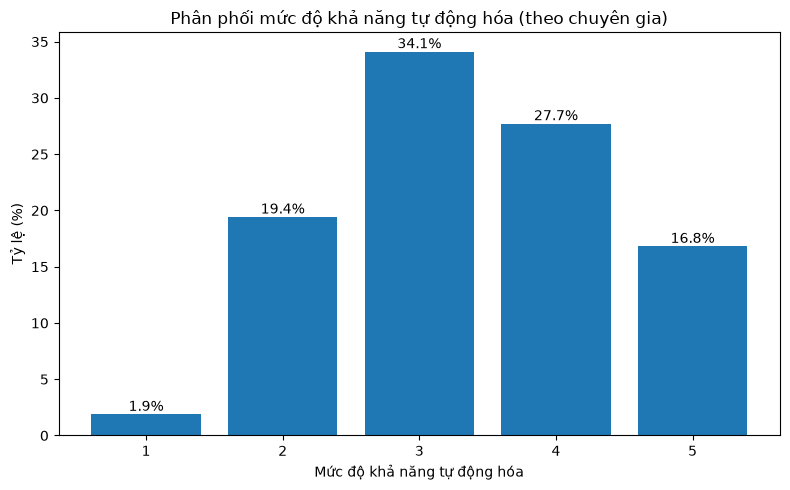

In [16]:
automation_capacity_pct = automation_capacity_counts / len(cs_expert) * 100

plt.figure(figsize=(8, 5))
plt.bar(automation_capacity_pct.index, automation_capacity_pct.values)

plt.title('Phân phối mức độ khả năng tự động hóa (theo chuyên gia)')
plt.xlabel('Mức độ khả năng tự động hóa')
plt.ylabel('Tỷ lệ (%)')
plt.xticks(automation_capacity_pct.index)

for x, y in zip(automation_capacity_pct.index, automation_capacity_pct.values):
    plt.text(x, y, f'{y:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Theo đánh giá của chuyên gia, mức độ khả năng tự động hóa (Automation Capacity Rating) trong các nhiệm vụ thuộc ngành CS phân bố như sau: chỉ 1.9% nhiệm vụ ở mức 1 (AI hầu như không thể tự làm), 19.4% ở mức 2; phần lớn (34.1%) tập trung ở mức 3 - trung bình; và 44.5% nhiệm vụ (mức 4 và 5 cộng lại) được đánh giá là AI có khả năng tự động hóa cao. Điều này cho thấy gần một nửa nhiệm vụ trong ngành CS đã được chuyên gia đánh giá là phù hợp về mặt công nghệ để AI Agent thực hiện, dù vẫn còn hơn 50% nhiệm vụ ở mức trung bình hoặc thấp, cần thêm nghiên cứu hoặc sự tham gia của con người.

In [17]:
# Tính Human Agency trung bình theo nghề - THEO CHUYÊN GIA
occupation_agency_expert = (
    cs_expert.groupby('Occupation (O*NET-SOC Title)')['Human Agency Scale Rating']
    .mean().round(2).sort_values()
)

# Top 10 nghề chuyên gia đánh giá cần ít con người nhất -> tiềm năng tự động hóa cao nhất
top10_low_agency_expert = occupation_agency_expert.head(10).reset_index()
top10_low_agency_expert.columns = ['Occupation', 'Human_Agency_Mean']
print('Top 10 nghề có tiềm năng tự động hóa cao nhất (theo chuyên gia)')
display(top10_low_agency_expert)

# Top 10 nghề cần con người nhất -> tiềm năng tự động hóa thấp nhất
bottom10_low_agency_expert = occupation_agency_expert.tail(10).reset_index()
bottom10_low_agency_expert.columns = ['Occupation', 'Human_Agency_Mean']
print('Top 10 nghề có tiềm năng tự động hóa thấp nhất (theo chuyên gia)')
display(bottom10_low_agency_expert)

Top 10 nghề có tiềm năng tự động hóa cao nhất (theo chuyên gia)


,Occupation,Human_Agency_Mean
0,Web Administrators,2.04
1,Web Developers,2.15
2,Computer User Support Specialists,2.21
3,Database Administrators,2.27
4,Computer Programmers,2.32
5,Computer Network Support Specialists,2.35
6,Software Quality Assurance Analysts and Testers,2.40
7,Computer Systems Analysts,2.59
8,Biostatisticians,2.60
9,Network and Computer Systems Administrators,2.67


Top 10 nghề có tiềm năng tự động hóa thấp nhất (theo chuyên gia)


,Occupation,Human_Agency_Mean
0,Statisticians,2.93
1,Business Intelligence Analysts,3.08
2,Computer Systems Engineers/Architects,3.22
3,Information Security Analysts,3.27
4,Clinical Data Managers,3.29
5,Health Informatics Specialists,3.32
6,Mathematicians,3.45
7,Computer and Information Research Scientists,3.73
8,Information Technology Project Managers,3.73
9,Video Game Designers,3.94


## **Phân tích mong muốn tự động hóa**
Người lao động muốn tự động hóa những công việc nào? Lý do là gì?

In [18]:
# Đếm số lượng cho từng mức độ
automation_desire_counts = cs_desires['Automation Desire Rating'].value_counts().sort_index()

# In kết quả
print("Phân phối mức độ mong muốn tự động hóa:")
for rating, count in automation_desire_counts.items():
    pct = count / len(cs_desires) * 100
    print(f"  Mức {rating}: {count} nhiệm vụ ({pct:.1f}%)")

Phân phối mức độ mong muốn tự động hóa:
  Mức 1: 124 nhiệm vụ (10.1%)
  Mức 2: 269 nhiệm vụ (22.0%)
  Mức 3: 350 nhiệm vụ (28.6%)
  Mức 4: 301 nhiệm vụ (24.6%)
  Mức 5: 181 nhiệm vụ (14.8%)


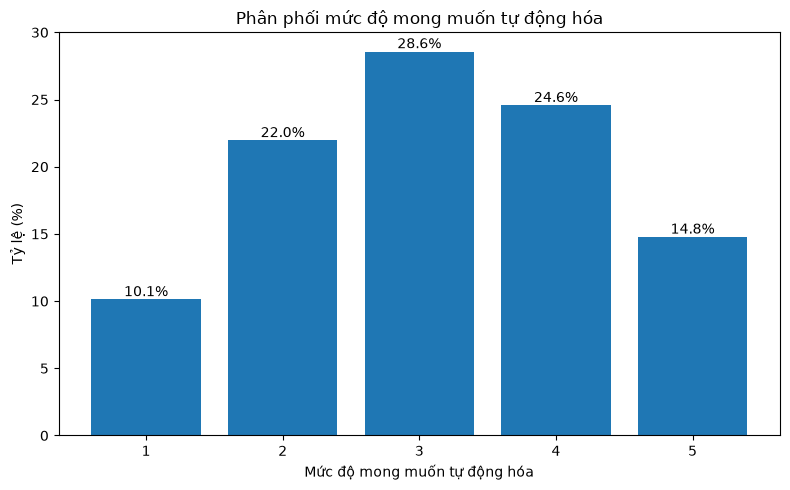

In [19]:
automation_desire_pct = automation_desire_counts / len(cs_desires) * 100

plt.figure(figsize=(8, 5))
plt.bar(automation_desire_pct.index, automation_desire_pct.values)

plt.title('Phân phối mức độ mong muốn tự động hóa')
plt.xlabel('Mức độ mong muốn tự động hóa')
plt.ylabel('Tỷ lệ (%)')
plt.xticks(automation_desire_pct.index)

for x, y in zip(automation_desire_pct.index, automation_desire_pct.values):
    plt.text(x, y, f'{y:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [20]:
reasons = cs_desires[[
    'Reasons for Human Agency - Physical',
    'Reasons for Human Agency - Control',
    'Reasons for Human Agency - Domain Knowledge',
    'Reasons for Human Agency - Empathy',
    'Reasons for Human Agency - Quality Oversight',
    'Reasons for Human Agency - Dynamic',
    'Reasons for Human Agency - Ethical',
]].sum()

for reason, count in reasons.items():
    pct = count / len(cs_desires) * 100
    print(f"  {reason}: {pct:.1f}%")

  Reasons for Human Agency - Physical: 12.9%
  Reasons for Human Agency - Control: 28.1%
  Reasons for Human Agency - Domain Knowledge: 33.6%
  Reasons for Human Agency - Empathy: 22.9%
  Reasons for Human Agency - Quality Oversight: 31.2%
  Reasons for Human Agency - Dynamic: 24.2%
  Reasons for Human Agency - Ethical: 17.3%


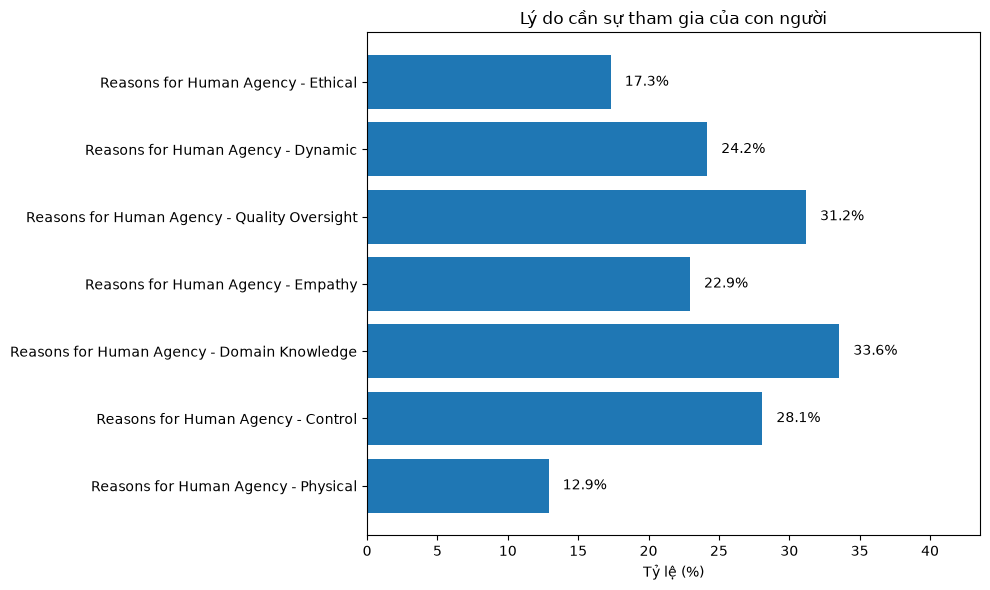

In [21]:
# Tính tỷ lệ % (giống logic ở cell 28)
reasons_pct = reasons / len(cs_desires) * 100

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
bars = plt.barh(reasons_pct.index, reasons_pct.values)

plt.xlabel('Tỷ lệ (%)')
plt.title('Lý do cần sự tham gia của con người')

# Hiển thị % trên từng thanh
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1,
             bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%',
             va='center')

plt.xlim(0, max(reasons_pct.values) + 10)
plt.tight_layout()
plt.show()

Trong số các lý do worker đưa ra để giải thích vì sao công việc cần sự tham gia của con người, "Domain Knowledge" (kiến thức chuyên môn) được chọn nhiều nhất (33.6%), tiếp theo là "Quality Oversight" - giám sát chất lượng (31.2%) và "Control" - kiểm soát công việc (28.1%). "Dynamic" - tính linh hoạt/thay đổi liên tục (24.2%) và "Empathy" - sự đồng cảm (22.9%) ít được chọn hơn. Hai lý do có tỷ lệ thấp nhất là "Ethical" - vấn đề đạo đức (17.3%) và "Physical" - yêu cầu thể chất (12.9%), điều này phù hợp với đặc thù công việc CS chủ yếu làm việc với máy tính và dữ liệu, ít liên quan đến yếu tố thể chất hoặc đạo đức trực tiếp.

Tổng thể, kết quả cho thấy trong ngành CS, lý do giữ con người trong công việc chủ yếu xuất phát từ yêu cầu chuyên môn và kiểm soát chất lượng, hơn là yếu tố cảm xúc hoặc thể chất.

In [22]:
# Tính trung bình Automation Desire theo nghề
occupation_auto = (cs_desires.groupby('Occupation (O*NET-SOC Title)')['Automation Desire Rating'].agg(['mean', 'count']).round(2))

occupation_auto.columns = ['Auto_Mean', 'Số_đánh_giá']
occupation_auto = occupation_auto.sort_values('Auto_Mean', ascending=False)

# Tạo 2 DataFrame
top10_occupations = occupation_auto.head(10).reset_index()
bottom10_occupations = occupation_auto.tail(10).reset_index()

# Hiển thị
print("TOP 10 NGHỀ CÓ MONG MUỐN TỰ ĐỘNG HÓA CAO NHẤT")
display(top10_occupations)

print("TOP 10 NGHỀ CÓ MONG MUỐN TỰ ĐỘNG HÓA THẤP NHẤT")
display(bottom10_occupations)

TOP 10 NGHỀ CÓ MONG MUỐN TỰ ĐỘNG HÓA CAO NHẤT


,Occupation (O*NET-SOC Title),Auto_Mean,Số_đánh_giá
0,Computer and Information Research Scientists,3.77,53
1,Statisticians,3.66,47
2,Network and Computer Systems Administrators,3.65,74
3,Clinical Data Managers,3.59,44
4,Web Administrators,3.53,58
5,Business Intelligence Analysts,3.37,49
6,Software Quality Assurance Analysts and Testers,3.23,81
7,Computer Systems Engineers/Architects,3.23,62
8,Information Security Analysts,3.18,45
9,Biostatisticians,3.18,33


TOP 10 NGHỀ CÓ MONG MUỐN TỰ ĐỘNG HÓA THẤP NHẤT


,Occupation (O*NET-SOC Title),Auto_Mean,Số_đánh_giá
0,Mathematicians,3.18,38
1,Web Developers,3.07,130
2,Computer User Support Specialists,2.95,58
3,Computer Programmers,2.93,99
4,Information Technology Project Managers,2.86,80
5,Video Game Designers,2.81,63
6,Computer Network Support Specialists,2.71,45
7,Health Informatics Specialists,2.68,40
8,Computer Systems Analysts,2.60,90
9,Database Administrators,2.53,36


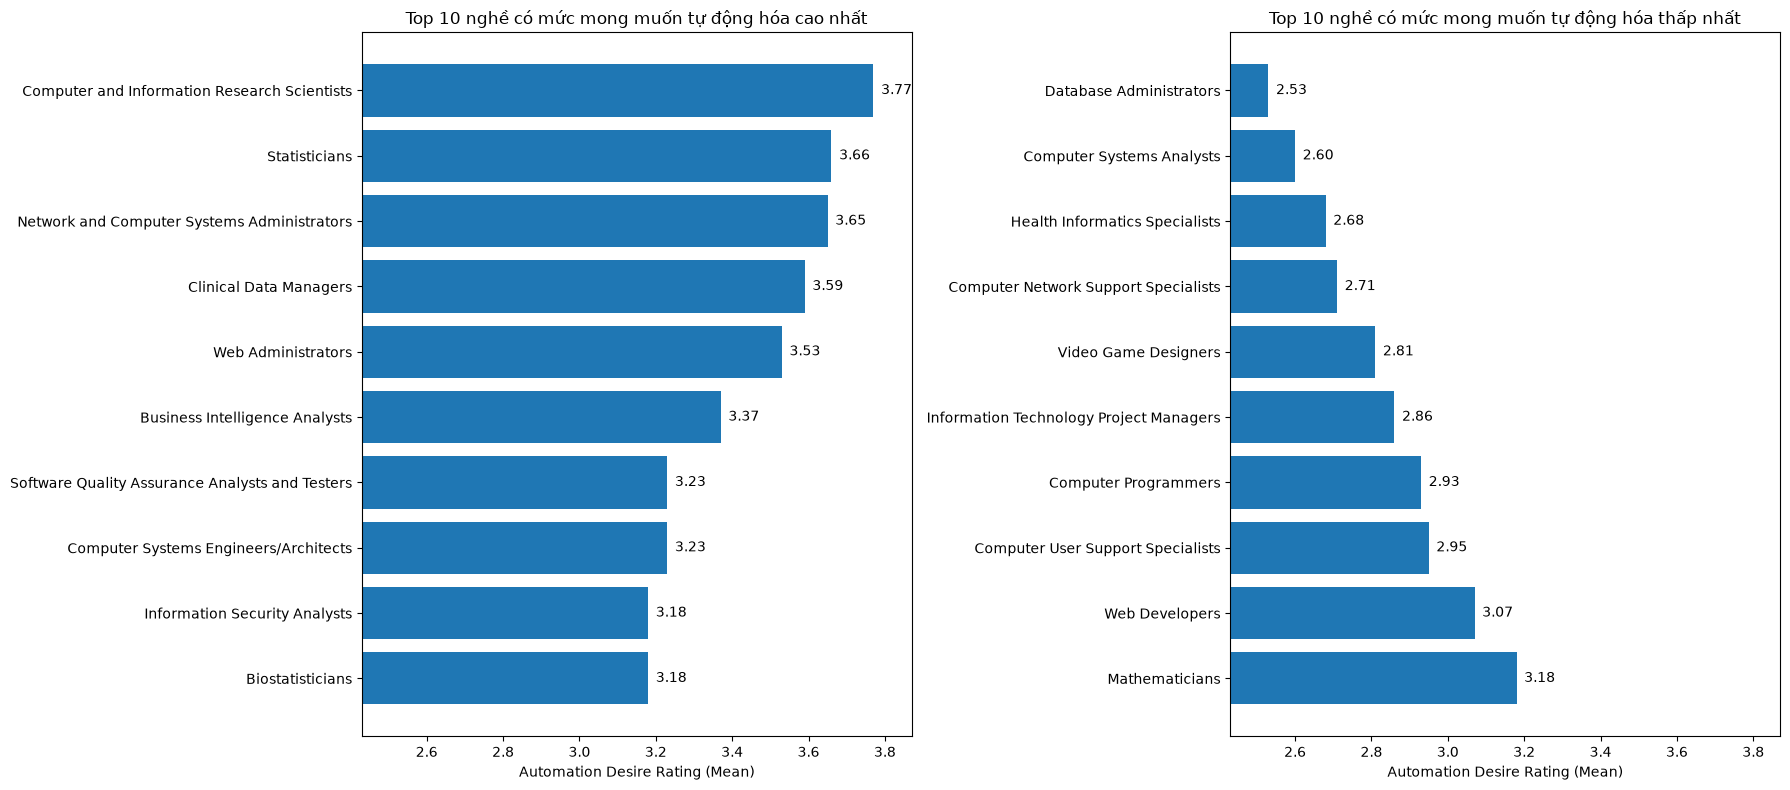

In [23]:
top10 = occupation_auto.head(10)
bottom10 = occupation_auto.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Biểu đồ Top 10
axes[0].barh(top10.index, top10['Auto_Mean'])
axes[0].set_title('Top 10 nghề có mức mong muốn tự động hóa cao nhất')
axes[0].set_xlabel('Automation Desire Rating (Mean)')
axes[0].invert_yaxis()

for i, v in enumerate(top10['Auto_Mean']):
    axes[0].text(v + 0.02, i, f'{v:.2f}', va='center')

# Biểu đồ Bottom 10
axes[1].barh(bottom10.index, bottom10['Auto_Mean'])
axes[1].set_title('Top 10 nghề có mức mong muốn tự động hóa thấp nhất')
axes[1].set_xlabel('Automation Desire Rating (Mean)')

for i, v in enumerate(bottom10['Auto_Mean']):
    axes[1].text(v + 0.02, i, f'{v:.2f}', va='center')

# Đồng nhất thang đo để dễ so sánh
xmin = occupation_auto['Auto_Mean'].min() - 0.1
xmax = occupation_auto['Auto_Mean'].max() + 0.1
axes[0].set_xlim(xmin, xmax)
axes[1].set_xlim(xmin, xmax)

plt.tight_layout()
plt.show()

Các nghề có mức mong muốn tự động hóa cao nhất tập trung vào nhóm phân tích/vận hành hệ thống mang tính kỹ thuật, lặp lại: "Computer and Information Research Scientists" (3.77), "Statisticians" (3.66), "Network and Computer Systems Administrators" (3.65). Ngược lại, các nghề có mức mong muốn tự động hóa thấp nhất nghiêng về nhóm cần tương tác trực tiếp hoặc ra quyết định mang tính cá nhân hóa cao như "Database Administrators" (2.53), "Computer Systems Analysts" (2.60), "Health Informatics Specialists" (2.68) - đây là những công việc đòi hỏi worker giữ vai trò kiểm soát hoặc tương tác với stakeholder nhiều hơn, nên mức độ mong muốn giao cho AI Agent thấp hơn.

## **So sánh Expert và Worker**

In [24]:
# Lấy dữ liệu chung theo Task ID
worker_avg = cs_desires.groupby('Task ID')['Automation Desire Rating'].mean()
expert_avg = cs_expert.groupby('Task ID')['Automation Capacity Rating'].mean()

combined = pd.DataFrame({
    'Worker_Desire': worker_avg,
    'Expert_Capacity': expert_avg
}).dropna()

combined['Gap'] = combined['Expert_Capacity'] - combined['Worker_Desire']

print(f"\nThống kê chênh lệch:")
print(f"   Trung bình: {combined['Gap'].mean():.3f}")
print(f"   Độ lệch chuẩn: {combined['Gap'].std():.3f}")

print("\nNhiệm vụ có chênh lệch lớn nhất:")
display(combined.nlargest(5, 'Gap'))
print("\nNhiệm vụ có chênh lệch nhỏ nhất:")
display(combined.nsmallest(5, 'Gap'))


Thống kê chênh lệch:
   Trung bình: 0.301
   Độ lệch chuẩn: 0.998

Nhiệm vụ có chênh lệch lớn nhất:


,Worker_Desire,Expert_Capacity,Gap
Task ID,,,
1313,1.666667,4.500000,2.833333
1283,2.285714,4.666667,2.380952
1299,2.166667,4.500000,2.333333
18991,2.333333,4.666667,2.333333
1285,2.750000,5.000000,2.250000



Nhiệm vụ có chênh lệch nhỏ nhất:


,Worker_Desire,Expert_Capacity,Gap
Task ID,,,
16212,3.666667,1.333333,-2.333333
1317,3.750000,1.500000,-2.250000
1319,3.714286,2.000000,-1.714286
14636,4.166667,2.500000,-1.666667
14626,3.333333,1.666667,-1.666667


Ngưỡng Worker Desire (mean): 3.115
Ngưỡng Expert Capacity (mean): 3.416

Phân bố nhiệm vụ theo 4 vùng:
  Low Priority: 47 nhiệm vụ (27.2%)
  Green Light: 47 nhiệm vụ (27.2%)
  R&D Opportunity: 42 nhiệm vụ (24.3%)
  Red Light: 37 nhiệm vụ (21.4%)


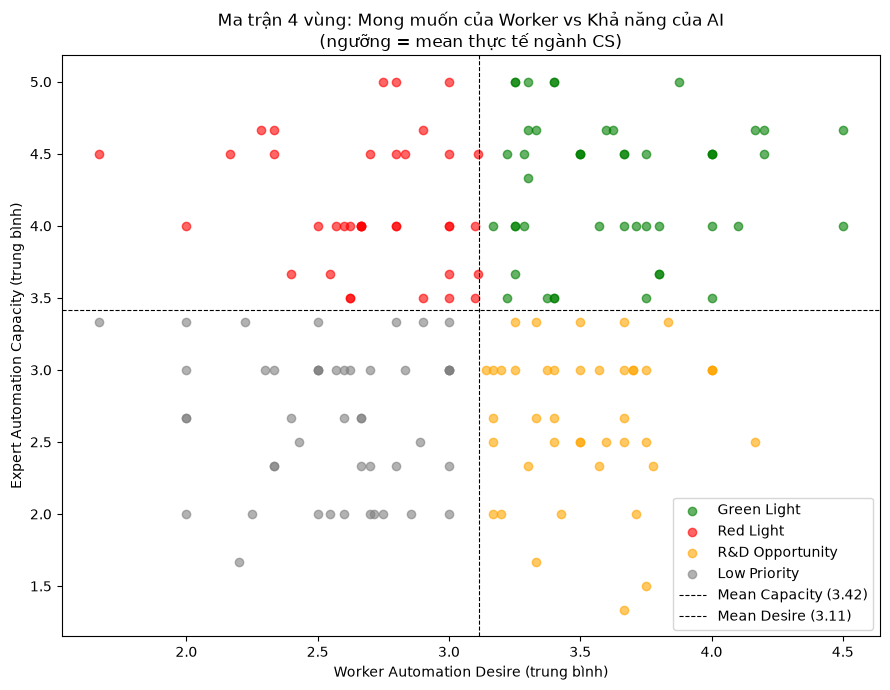

In [25]:
# Ngưỡng động: dùng trung bình thực tế của ngành CS
desire_threshold = combined['Worker_Desire'].mean()
capacity_threshold = combined['Expert_Capacity'].mean()

print(f"Ngưỡng Worker Desire (mean): {desire_threshold:.3f}")
print(f"Ngưỡng Expert Capacity (mean): {capacity_threshold:.3f}")

def classify_zone(row):
    desire_high = row['Worker_Desire'] > desire_threshold
    capacity_high = row['Expert_Capacity'] > capacity_threshold
    if desire_high and capacity_high:
        return 'Green Light'
    elif capacity_high and not desire_high:
        return 'Red Light'
    elif desire_high and not capacity_high:
        return 'R&D Opportunity'
    else:
        return 'Low Priority'

combined['Zone'] = combined.apply(classify_zone, axis=1)

print("\nPhân bố nhiệm vụ theo 4 vùng:")
zone_counts = combined['Zone'].value_counts()
for zone, count in zone_counts.items():
    pct = count / len(combined) * 100
    print(f"  {zone}: {count} nhiệm vụ ({pct:.1f}%)")

# Scatter plot — thêm đường mean thay vì đường 3
plt.figure(figsize=(9, 7))

colors = {'Green Light': 'green', 'Red Light': 'red',
          'R&D Opportunity': 'orange', 'Low Priority': 'gray'}

for zone, color in colors.items():
    subset = combined[combined['Zone'] == zone]
    plt.scatter(subset['Worker_Desire'], subset['Expert_Capacity'],
                label=zone, color=color, alpha=0.6)

plt.axhline(capacity_threshold, color='black', linestyle='--', linewidth=0.8,
            label=f'Mean Capacity ({capacity_threshold:.2f})')
plt.axvline(desire_threshold, color='black', linestyle='--', linewidth=0.8,
            label=f'Mean Desire ({desire_threshold:.2f})')

plt.xlabel('Worker Automation Desire (trung bình)')
plt.ylabel('Expert Automation Capacity (trung bình)')
plt.title('Ma trận 4 vùng: Mong muốn của Worker vs Khả năng của AI\n(ngưỡng = mean thực tế ngành CS)')
plt.legend()
plt.tight_layout()
plt.show()

Khi kết hợp góc nhìn của worker (ngưỡng Desire = 3.115) và chuyên gia 
(ngưỡng Capacity = 3.416), 173 nhiệm vụ ngành CS được phân vào 4 vùng 
với tỷ lệ khá cân bằng — phản ánh sự đa dạng thực sự trong mức độ sẵn 
sàng triển khai AI Agent.

Vùng "Green Light" và "Low Priority" cùng chiếm tỷ lệ cao nhất (27.2% - 
47 nhiệm vụ mỗi vùng). Green Light là nhóm ưu tiên triển khai ngay: cả 
worker lẫn chuyên gia đều đồng thuận AI có thể và nên đảm nhận các nhiệm 
vụ này. Low Priority ngược lại — cả hai phía đều chưa sẵn sàng, không 
cần đầu tư trong ngắn hạn.

Đáng chú ý hơn là sự chênh lệch giữa "R&D Opportunity" (24.3%) và "Red 
Light" (21.4%). R&D Opportunity cho thấy worker đang muốn tự động hóa 
nhiều hơn những gì AI hiện tại có thể làm được — đây là tín hiệu tốt cho 
hướng đầu tư công nghệ. Trong khi đó, Red Light tiết lộ một nghịch lý: 
AI đã đủ năng lực nhưng worker chưa muốn giao — rào cản không đến từ 
giới hạn công nghệ mà từ yếu tố con người: tâm lý, lo ngại mất quyền 
kiểm soát, và văn hóa làm việc.

Tổng thể, hơn một nửa nhiệm vụ (Green Light + R&D Opportunity = 51.5%) 
phản ánh mong muốn tích cực từ worker, cho thấy ngành CS có độ sẵn sàng 
tương đối cao với AI Agent. Tuy nhiên, tỷ lệ Red Light gần bằng Green 
Light là lời nhắc nhở rằng triển khai thành công không chỉ cần công nghệ 
đủ tốt — mà còn cần chiến lược quản lý thay đổi phù hợp.

In [26]:
combined_named = combined.reset_index().merge(
    cs_task[['Task ID', 'Occupation (O*NET-SOC Title)', 'Task']].drop_duplicates('Task ID'),
    on='Task ID', how='left'
)

for zone in ['Green Light', 'Red Light', 'R&D Opportunity', 'Low Priority']:
    print(f"\n- {zone} (5 ví dụ): ")
    display(combined_named[combined_named['Zone'] == zone][
        ['Occupation (O*NET-SOC Title)', 'Task', 'Worker_Desire', 'Expert_Capacity']
    ].head(5))


- Green Light (5 ví dụ): 


,Occupation (O*NET-SOC Title),Task,Worker_Desire,Expert_Capacity
1,Computer Programmers,Compile and write documentation of program dev...,3.625,4.666667
6,Computer Programmers,"Investigate whether networks, workstations, th...",3.400,5.000000
13,Computer User Support Specialists,Maintain records of daily data communication t...,4.500,4.666667
18,Database Administrators,"Test programs or databases, correct errors, an...",3.250,4.000000
26,Network and Computer Systems Administrators,Operate master consoles to monitor the perform...,3.500,4.500000



- Red Light (5 ví dụ): 


,Occupation (O*NET-SOC Title),Task,Worker_Desire,Expert_Capacity
2,Computer Programmers,"Write, update, and maintain computer programs ...",3.111111,4.5
4,Computer Programmers,"Write, analyze, review, and rewrite programs, ...",3.100000,3.5
5,Computer Programmers,Write or contribute to instructions or manuals...,2.800000,4.0
7,Computer Programmers,Prepare detailed workflow charts and diagrams ...,3.000000,5.0
8,Computer Programmers,Perform systems analysis and programming tasks...,2.625000,3.5



- R&D Opportunity (5 ví dụ): 


,Occupation (O*NET-SOC Title),Task,Worker_Desire,Expert_Capacity
23,Network and Computer Systems Administrators,Perform data backups and disaster recovery ope...,3.750000,1.500000
24,Network and Computer Systems Administrators,Maintain and administer computer networks and ...,3.500000,2.500000
25,Network and Computer Systems Administrators,"Plan, coordinate, and implement network securi...",3.714286,2.000000
29,Network and Computer Systems Administrators,Recommend changes to improve systems and netwo...,3.333333,2.666667
30,Network and Computer Systems Administrators,Monitor network performance to determine wheth...,3.666667,3.333333



- Low Priority (5 ví dụ): 


,Occupation (O*NET-SOC Title),Task,Worker_Desire,Expert_Capacity
0,Computer Programmers,Correct errors by making appropriate changes a...,3.000000,3.000000
3,Computer Programmers,"Perform or direct revision, repair, or expansi...",2.500000,3.000000
9,Computer Programmers,"Assign, coordinate, and review work and activi...",2.333333,2.333333
15,Computer User Support Specialists,"Develop training materials and procedures, or ...",3.000000,2.333333
16,Computer User Support Specialists,"Prepare evaluations of software or hardware, a...",2.625000,3.000000


## **Worker đang dùng LLM cho loại tác vụ gì?**

In [27]:
import re

# Từ khóa đặc trưng cho 2 nhóm
routine_keywords = [
    'review', 'check', 'log', 'update', 'compile', 'monitor', 'record',
    'report', 'maintain', 'test', 'verify', 'document', 'track', 'backup',
    'schedule', 'install', 'configure', 'scan', 'audit', 'collect'
]
creative_keywords = [
    'design', 'evaluate', 'recommend', 'resolve', 'develop', 'create',
    'analyze', 'assess', 'plan', 'advise', 'consult', 'lead', 'research',
    'investigate', 'architect', 'optimize', 'innovate', 'strategize', 'conceptualize'
]

def classify_task(task_text):
    if not isinstance(task_text, str):
        return 'Unknown'
    task_lower = task_text.lower()
    routine_score = sum(1 for kw in routine_keywords if kw in task_lower)
    creative_score = sum(1 for kw in creative_keywords if kw in task_lower)
    if routine_score > creative_score:
        return 'Routine/Repetitive'
    elif creative_score > routine_score:
        return 'Creative/Judgment'
    else:
        return 'Mixed'

cs_task['Task_Type'] = cs_task['Task'].apply(classify_task)

type_counts = cs_task['Task_Type'].value_counts()
print("Phân loại Task Statement trong ngành CS:")
for t, c in type_counts.items():
    print(f"  {t}: {c} task ({c/len(cs_task)*100:.1f}%)")

Phân loại Task Statement trong ngành CS:
  Routine/Repetitive: 96 task (36.8%)
  Mixed: 87 task (33.3%)
  Creative/Judgment: 78 task (29.9%)


Automation Capacity Rating trung bình theo loại task:
  Routine/Repetitive: 3.731/5.0
  Mixed: 3.338/5.0
  Creative/Judgment: 3.022/5.0


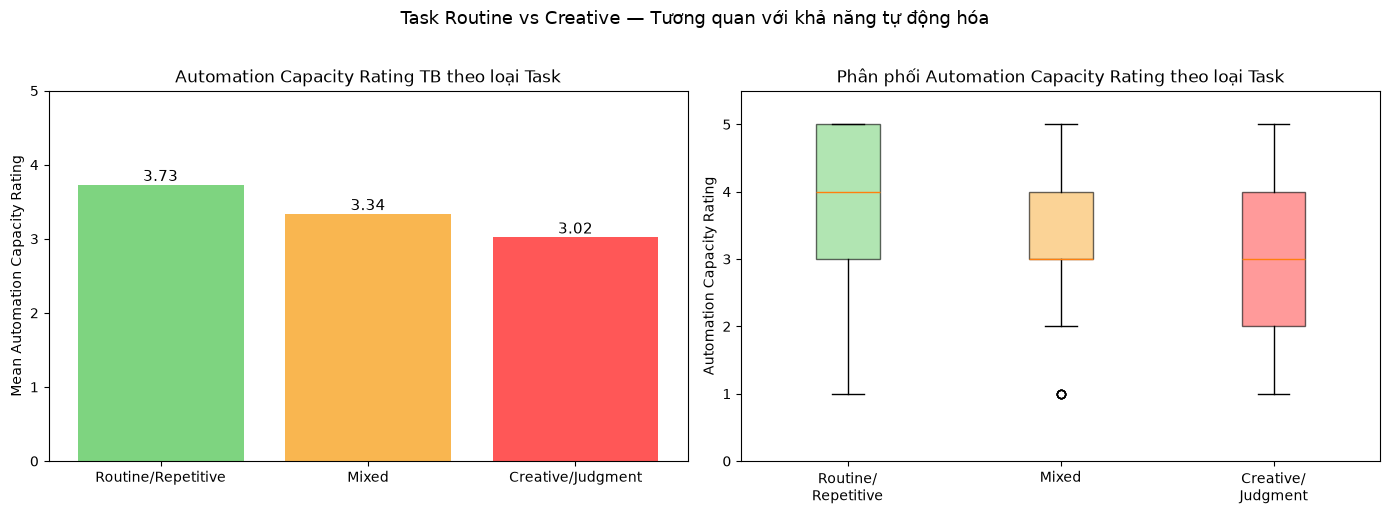

In [28]:
# Gộp với expert để xem tương quan Task_Type và Automation Capacity Rating
cs_task_expert = cs_task[['Task ID', 'Task_Type']].merge(
    cs_expert[['Task ID', 'Automation Capacity Rating']],
    on='Task ID', how='inner'
)

task_type_capacity = cs_task_expert.groupby('Task_Type')['Automation Capacity Rating'].mean().round(3).sort_values(ascending=False)
print("Automation Capacity Rating trung bình theo loại task:")
for t, v in task_type_capacity.items():
    print(f"  {t}: {v:.3f}/5.0")

# Biểu đồ so sánh
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: mean capacity theo task type
colors_map = {'Routine/Repetitive': '#7ED480', 'Creative/Judgment': '#FF5757', 'Mixed': '#F9B650'}
bars = axes[0].bar(task_type_capacity.index, task_type_capacity.values,
                   color=[colors_map.get(t, 'gray') for t in task_type_capacity.index])
axes[0].set_title('Automation Capacity Rating TB theo loại Task')
axes[0].set_ylabel('Mean Automation Capacity Rating')
axes[0].set_ylim(0, 5)
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.05, f'{h:.2f}', ha='center', fontsize=11)

# Boxplot phân phối
data_by_type = [
    cs_task_expert[cs_task_expert['Task_Type'] == t]['Automation Capacity Rating'].dropna().values
    for t in ['Routine/Repetitive', 'Mixed', 'Creative/Judgment']
]
bp = axes[1].boxplot(data_by_type, tick_labels=['Routine/\nRepetitive', 'Mixed', 'Creative/\nJudgment'],
                     patch_artist=True)
box_colors = ["#7ED480", "#F9B650", "#FF5757"]
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_title('Phân phối Automation Capacity Rating theo loại Task')
axes[1].set_ylabel('Automation Capacity Rating')
axes[1].set_ylim(0, 5.5)

plt.suptitle('Task Routine vs Creative — Tương quan với khả năng tự động hóa', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## **Người dùng LLM nhiều → Muốn tự động hóa nhiều hơn không?**

In [29]:
# Gộp metadata với desires theo Worker ID (hoặc Occupation nếu không có Worker ID chung)
# Dùng Occupation để nối
meta_desire = cs_metadata.merge(
    cs_desires[['Occupation (O*NET-SOC Title)', 'Automation Desire Rating']],
    on='Occupation (O*NET-SOC Title)',
    how='inner'
)

# Mapping đúng theo giá trị thực tế
llm_use_map_real = {
    "Yes, I use them every day in my work.": "Always",
    "Yes, I use them every week in my work.": "Often",
    "Yes, I have used them occasionally for specific tasks.": "Sometimes",
    "No, I have not used them for any work-related activities.": "Never",
    "No, I've never heard of them.": "Never"
}

meta_desire['LLM_Use_Category'] = meta_desire['LLM Use in Work'].map(llm_use_map_real)

freq_score = {'Never': 0, 'Sometimes': 1, 'Often': 2, 'Always': 3}
meta_desire['LLM_Use_Numeric'] = meta_desire['LLM_Use_Category'].map(freq_score)

llm_desire_avg = (
    meta_desire.groupby('LLM_Use_Category')['Automation Desire Rating']
    .agg(['mean', 'count']).round(3)
)
llm_desire_avg.columns = ['Desire_Mean', 'Count']

order = ['Never', 'Sometimes', 'Often', 'Always']
llm_desire_avg = llm_desire_avg.reindex([o for o in order if o in llm_desire_avg.index])

print("Automation Desire Rating TB theo mức độ sử dụng LLM trong công việc:")
print(llm_desire_avg.to_string())

valid = meta_desire[['LLM_Use_Numeric', 'Automation Desire Rating']].dropna()
corr = valid['LLM_Use_Numeric'].corr(valid['Automation Desire Rating'])
print(f"\nHệ số tương quan Pearson: {corr:.3f}")

Automation Desire Rating TB theo mức độ sử dụng LLM trong công việc:
                  Desire_Mean  Count
LLM_Use_Category                    
Never                   3.008   1193
Sometimes               3.032   5438
Often                   3.043   4321
Always                  3.133  10199

Hệ số tương quan Pearson: 0.039


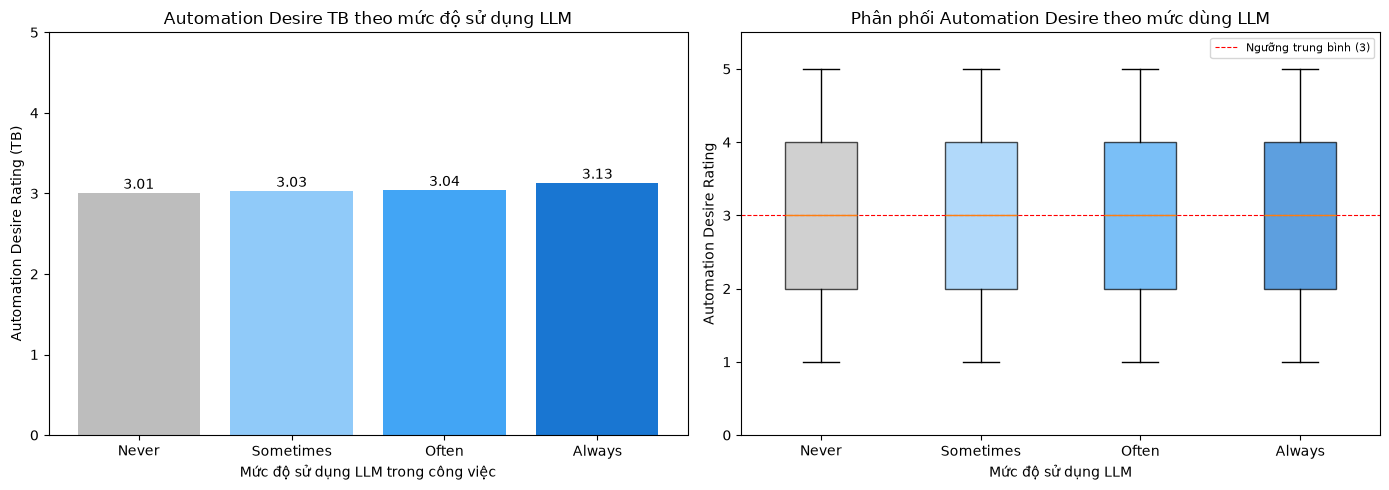

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if len(llm_desire_avg) > 0:
    # Bar chart
    axes[0].bar(llm_desire_avg.index, llm_desire_avg['Desire_Mean'],
                color=['#BDBDBD', '#90CAF9', '#42A5F5', '#1976D2', '#0D47A1'][:len(llm_desire_avg)])
    axes[0].set_title('Automation Desire TB theo mức độ sử dụng LLM')
    axes[0].set_xlabel('Mức độ sử dụng LLM trong công việc')
    axes[0].set_ylabel('Automation Desire Rating (TB)')
    axes[0].set_ylim(0, 5)
    for i, (idx, row) in enumerate(llm_desire_avg.iterrows()):
        axes[0].text(i, row['Desire_Mean'] + 0.05, f"{row['Desire_Mean']:.2f}", ha='center')
    
    # Box plot — lấy từ LLM_Use_Category
    groups = [meta_desire[meta_desire['LLM_Use_Category'] == cat]['Automation Desire Rating'].dropna()
              for cat in llm_desire_avg.index]
    bp = axes[1].boxplot(groups, tick_labels=llm_desire_avg.index, patch_artist=True)
    box_colors_list = ['#BDBDBD', '#90CAF9', '#42A5F5', '#1976D2', '#0D47A1']
    for patch, color in zip(bp['boxes'], box_colors_list[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[1].set_title('Phân phối Automation Desire theo mức dùng LLM')
    axes[1].set_xlabel('Mức độ sử dụng LLM')
    axes[1].set_ylabel('Automation Desire Rating')
    axes[1].set_ylim(0, 5.5)
    axes[1].axhline(3, color='red', linestyle='--', linewidth=0.8, label='Ngưỡng trung bình (3)')
    axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Mức độ sử dụng LLM trong công việc **không tương quan rõ ràng** với mong muốn tự động hóa của worker. Tất cả 4 nhóm (Never / Sometimes / Often / Always) đều có Automation Desire Rating trung bình ngang nhau (~3.01–3.13), chênh lệch chỉ 0.12 điểm.

Kết quả này **thách thức giả thuyết trực giác** rằng worker quen dùng LLM sẽ sẵn sàng hơn với AI Agent. Có thể vì:

1. **LLM và AI Agent là 2 thứ khác nhau trong tâm lý worker**: Dùng ChatGPT như công cụ hỗ trợ (LLM) khác hoàn toàn với giao hệ thống tự động hóa hoàn toàn công việc (Agent) — mức độ kiểm soát và trách nhiệm khác nhau.

2. **LLM Usage không phản ánh "AI Maturity" thật sự**: Worker có thể dùng LLM thường xuyên nhưng vẫn lo mất quyền kiểm soát khi AI tự quyết định.

3. **Difference giữa "dùng AI như công cụ" vs "giao công việc cho AI"**: Hai tâm lý hoàn toàn khác nhau.

**Hàm ý:** Triển khai AI Agent không nên chủ yếu dựa vào "worker quen dùng LLM hay không" — cần phân tích sâu hơn các yếu tố khác như **Readiness Score (Capacity × Desire)** hoặc **thái độ riêng từng nhóm task/nghề**.

## **Readiness Score**

Sử dụng công thức **Readiness Score = 0.5 × Expert_Capacity + 0.5 × Worker_Desire** (trọng số cân bằng dựa trên tỷ lệ Green Light 52% vs Red Light 48%), bài phân tích xác định được các task và nghề nên ưu tiên triển khai AI Agent

In [31]:
readiness = combined_named[['Task ID', 'Occupation (O*NET-SOC Title)', 'Task',
                             'Worker_Desire', 'Expert_Capacity', 'Zone']].copy()

readiness['Readiness_Score'] = (
    0.5 * readiness['Expert_Capacity'] + 0.5 * readiness['Worker_Desire']
).round(3)

readiness = readiness.sort_values('Readiness_Score', ascending=False).reset_index(drop=True)
readiness.index += 1  # Bắt đầu từ 1

print("TOP 10 TASK CÓ READINESS SCORE CAO NHẤT — Nên triển khai AI Agent ngay:")
display(readiness[['Occupation (O*NET-SOC Title)', 'Task', 'Worker_Desire',
                   'Expert_Capacity', 'Readiness_Score', 'Zone']].head(10))


TOP 10 TASK CÓ READINESS SCORE CAO NHẤT — Nên triển khai AI Agent ngay:


,Occupation (O*NET-SOC Title),Task,Worker_Desire,Expert_Capacity,Readiness_Score,Zone
1,Computer User Support Specialists,Maintain records of daily data communication t...,4.500000,4.666667,4.583,Green Light
2,Network and Computer Systems Administrators,"Configure, monitor, and maintain email applica...",3.875000,5.000000,4.438,Green Light
3,Web Developers,Back up files from Web sites to local director...,4.200000,4.666667,4.433,Green Light
4,Network and Computer Systems Administrators,Perform routine network startup and shutdown p...,4.166667,4.666667,4.417,Green Light
5,Web Administrators,Back up or modify applications and related dat...,4.200000,4.500000,4.350,Green Light
6,Mathematicians,Perform computations and apply methods of nume...,4.000000,4.500000,4.250,Green Light
7,Web Administrators,Set up or maintain monitoring tools on Web ser...,4.000000,4.500000,4.250,Green Light
8,Statisticians,"Report results of statistical analyses, includ...",4.500000,4.000000,4.250,Green Light
9,Web Administrators,Install or configure Web server software or ha...,4.000000,4.500000,4.250,Green Light
10,Software Quality Assurance Analysts and Testers,Document test procedures to ensure replicabili...,3.400000,5.000000,4.200,Green Light


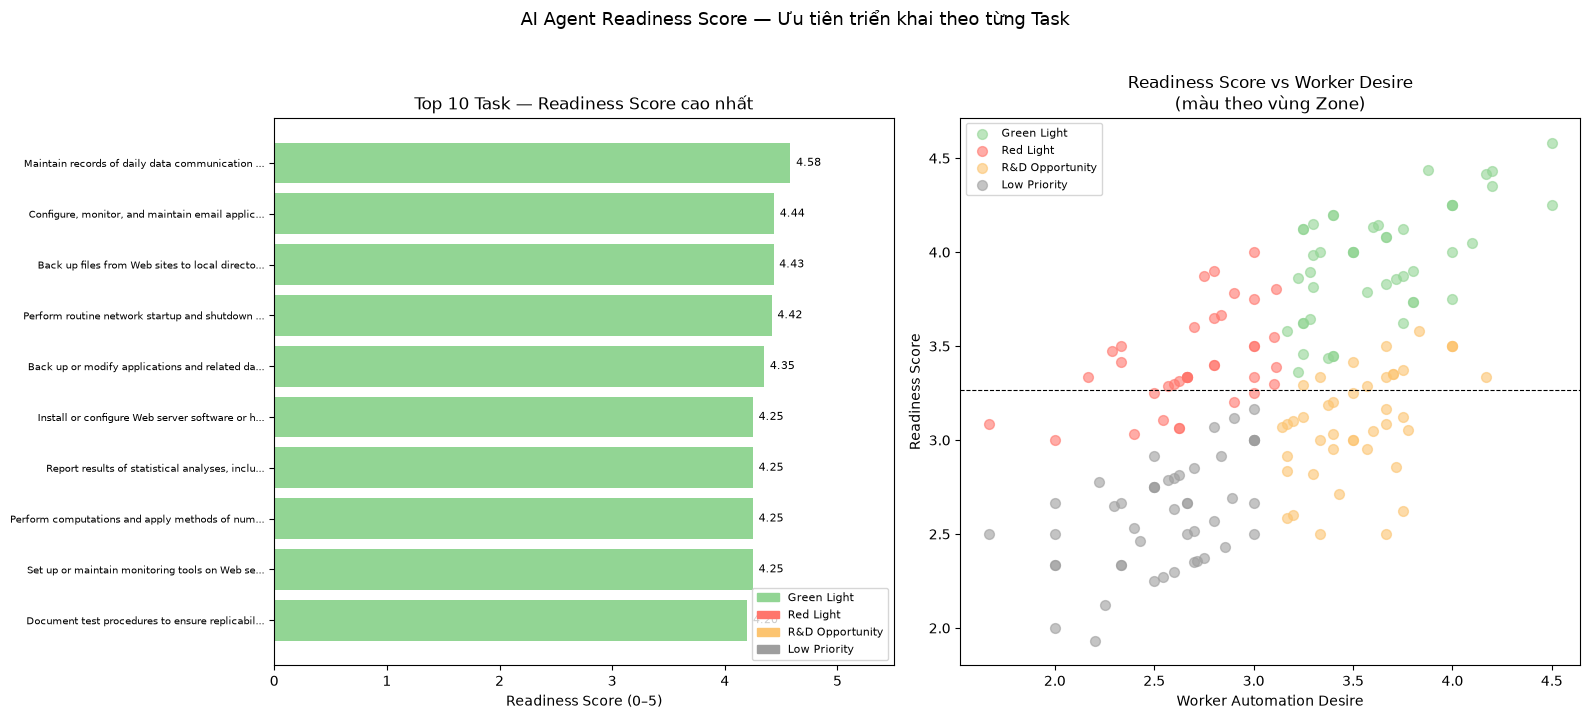

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 10 task theo Readiness Score
top10 = readiness.head(10).sort_values('Readiness_Score')
task_labels = [
    (row['Task'][:45] + '...' if len(row['Task']) > 45 else row['Task'])
    for _, row in top10.iterrows()
]
zone_color_map = {'Green Light': "#92D594", 'Red Light': "#FF766C",
                  'R&D Opportunity': "#FCC470", 'Low Priority': '#9E9E9E'}
bar_colors = [zone_color_map.get(z, 'gray') for z in top10['Zone']]

bars3 = axes[0].barh(range(len(top10)), top10['Readiness_Score'], color=bar_colors)
axes[0].set_yticks(range(len(top10)))
axes[0].set_yticklabels([task_labels[i] for i in range(len(top10))], fontsize=7)
axes[0].set_xlabel('Readiness Score (0–5)')
axes[0].set_title('Top 10 Task — Readiness Score cao nhất')
axes[0].set_xlim(0, 5.5)
for bar in bars3:
    w = bar.get_width()
    axes[0].text(w + 0.05, bar.get_y() + bar.get_height()/2, f'{w:.2f}', va='center', fontsize=8)

# Legend zone màu
patches = [mpatches.Patch(color=c, label=z) for z, c in zone_color_map.items()]
axes[0].legend(handles=patches, fontsize=8, loc='lower right')

# Scatter: Readiness Score vs Expert Capacity (colored by Zone)
for zone, color in zone_color_map.items():
    sub = readiness[readiness['Zone'] == zone]
    axes[1].scatter(sub['Worker_Desire'], sub['Readiness_Score'],
                    label=zone, color=color, alpha=0.6, s=50)
axes[1].set_xlabel('Worker Automation Desire')
axes[1].set_ylabel('Readiness Score')
axes[1].set_title('Readiness Score vs Worker Desire\n(màu theo vùng Zone)')
axes[1].legend(fontsize=8)
axes[1].axhline(readiness['Readiness_Score'].mean(), color='black',
                linestyle='--', linewidth=0.8, label='TB Readiness')

plt.suptitle('AI Agent Readiness Score — Ưu tiên triển khai theo từng Task', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


**Top 10 task có Readiness Score cao nhất** là ứng viên lý tưởng cho Phase 1 triển khai — nơi cả chuyên gia lẫn worker đều nhất trí rằng AI vừa có khả năng thực hiện lẫn vừa được mong muốn.


Readiness Score TB theo nghề (Top 10 ưu tiên triển khai AI Agent):


,Readiness_Mean,Num_Tasks
Occupation (O*NET-SOC Title),,
Web Administrators,3.872,11
Web Developers,3.567,13
Statisticians,3.550,6
Software Quality Assurance Analysts and Testers,3.531,17
Network and Computer Systems Administrators,3.512,10
Computer User Support Specialists,3.485,7
Biostatisticians,3.446,5
Computer Programmers,3.394,11
Business Intelligence Analysts,3.282,6



Readiness Score TB theo nghề (Bottom 10 — ít ưu tiên nhất):


,Readiness_Mean,Num_Tasks
Occupation (O*NET-SOC Title),,
Computer and Information Research Scientists,3.243,6
Computer Network Support Specialists,3.216,9
Database Administrators,3.152,6
Information Security Analysts,3.110,5
Computer Systems Engineers/Architects,3.109,10
Mathematicians,3.081,5
Computer Systems Analysts,3.006,9
Information Technology Project Managers,2.734,8
Health Informatics Specialists,2.727,9


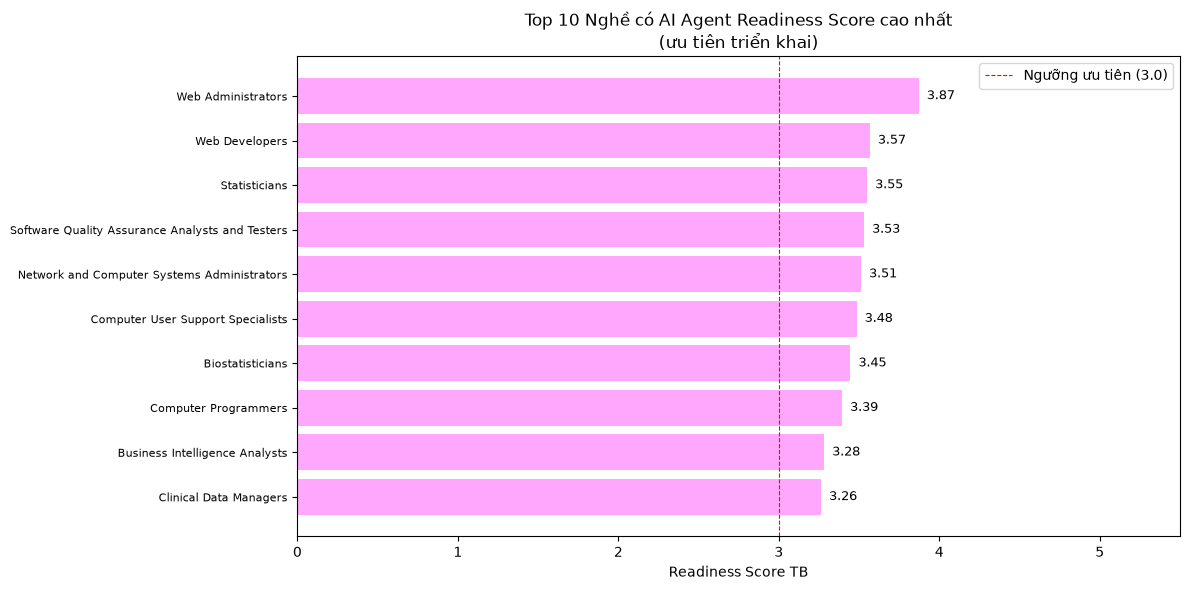

In [33]:
# Readiness Score trung bình theo từng nghề (occupation)
occ_readiness = (
    readiness.groupby('Occupation (O*NET-SOC Title)')['Readiness_Score']
    .agg(['mean', 'count']).round(3).sort_values('mean', ascending=False)
)
occ_readiness.columns = ['Readiness_Mean', 'Num_Tasks']

print("Readiness Score TB theo nghề (Top 10 ưu tiên triển khai AI Agent):")
display(occ_readiness.head(10))
print("\nReadiness Score TB theo nghề (Bottom 10 — ít ưu tiên nhất):")
display(occ_readiness.tail(10))

# Bar chart top 10 nghề
fig, ax = plt.subplots(figsize=(12, 6))
top10_occ = occ_readiness.head(10).sort_values('Readiness_Mean')
ax.barh(range(len(top10_occ)), top10_occ['Readiness_Mean'], color="#FFA7FC")
ax.set_yticks(range(len(top10_occ)))
ax.set_yticklabels([o[:50] + '...' if len(o) > 50 else o for o in top10_occ.index], fontsize=8)
ax.set_xlabel('Readiness Score TB')
ax.set_title('Top 10 Nghề có AI Agent Readiness Score cao nhất\n(ưu tiên triển khai)')
ax.set_xlim(0, 5.5)
for i, (idx, row) in enumerate(top10_occ.iterrows()):
    ax.text(row['Readiness_Mean'] + 0.05, i, f"{row['Readiness_Mean']:.2f}", va='center', fontsize=9)
ax.axvline(3, color='red', linestyle='--', linewidth=0.8, label='Ngưỡng ưu tiên (3.0)')
ax.legend()
plt.tight_layout()
plt.show()


**Phân tích theo nghề** cho thấy không phải tất cả vị trí CS đều sẵn sàng như nhau. Một số nghề (ví dụ: Web Administrators, Computer Programmers) có Readiness Score cao, trong khi các vị trí đòi hỏi nhiều phán đoán chiến lược (Project Managers, Architects) có score thấp hơn — phù hợp với bản chất công việc.